In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl

In [2]:
df = pd.read_csv("data/MICRODADOS_ENEM_2020.csv", encoding="cp860", sep=";")

In [3]:
df = df.sample(2_000_000, random_state=42)
# I will consider the score in portuguese test
df["target"] = df["NU_NOTA_LC"]
df["TP_DEPENDENCIA_ADM_ESC"] = df["TP_DEPENDENCIA_ADM_ESC"].fillna(-1)

# put everyone above 50 years to the class of 50 years
df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"].apply(lambda x : x if x < 16 else 15)

In [32]:
def test(df):
    return (df.target > 500).mean()
df.groupby(["Q006"]).apply(test)

Q006
A    0.163473
B    0.217568
C    0.274885
D    0.318391
E    0.379602
F    0.421006
G    0.491095
H    0.538749
I    0.580145
J    0.611574
K    0.623943
L    0.634522
M    0.633629
N    0.631868
O    0.639298
P    0.638867
Q    0.604400
dtype: float64

In [30]:
df.columns.tolist()

['NU_INSCRICAO',
 'NU_ANO',
 'TP_FAIXA_ETARIA',
 'TP_SEXO',
 'TP_ESTADO_CIVIL',
 'TP_COR_RACA',
 'TP_NACIONALIDADE',
 'TP_ST_CONCLUSAO',
 'TP_ANO_CONCLUIU',
 'TP_ESCOLA',
 'TP_ENSINO',
 'IN_TREINEIRO',
 'CO_MUNICIPIO_ESC',
 'NO_MUNICIPIO_ESC',
 'CO_UF_ESC',
 'SG_UF_ESC',
 'TP_DEPENDENCIA_ADM_ESC',
 'TP_LOCALIZACAO_ESC',
 'TP_SIT_FUNC_ESC',
 'CO_MUNICIPIO_PROVA',
 'NO_MUNICIPIO_PROVA',
 'CO_UF_PROVA',
 'SG_UF_PROVA',
 'TP_PRESENCA_CN',
 'TP_PRESENCA_CH',
 'TP_PRESENCA_LC',
 'TP_PRESENCA_MT',
 'CO_PROVA_CN',
 'CO_PROVA_CH',
 'CO_PROVA_LC',
 'CO_PROVA_MT',
 'NU_NOTA_CN',
 'NU_NOTA_CH',
 'NU_NOTA_LC',
 'NU_NOTA_MT',
 'TX_RESPOSTAS_CN',
 'TX_RESPOSTAS_CH',
 'TX_RESPOSTAS_LC',
 'TX_RESPOSTAS_MT',
 'TP_LINGUA',
 'TX_GABARITO_CN',
 'TX_GABARITO_CH',
 'TX_GABARITO_LC',
 'TX_GABARITO_MT',
 'TP_STATUS_REDACAO',
 'NU_NOTA_COMP1',
 'NU_NOTA_COMP2',
 'NU_NOTA_COMP3',
 'NU_NOTA_COMP4',
 'NU_NOTA_COMP5',
 'NU_NOTA_REDACAO',
 'Q001',
 'Q002',
 'Q003',
 'Q004',
 'Q005',
 'Q006',
 'Q007',
 'Q008',
 'Q009

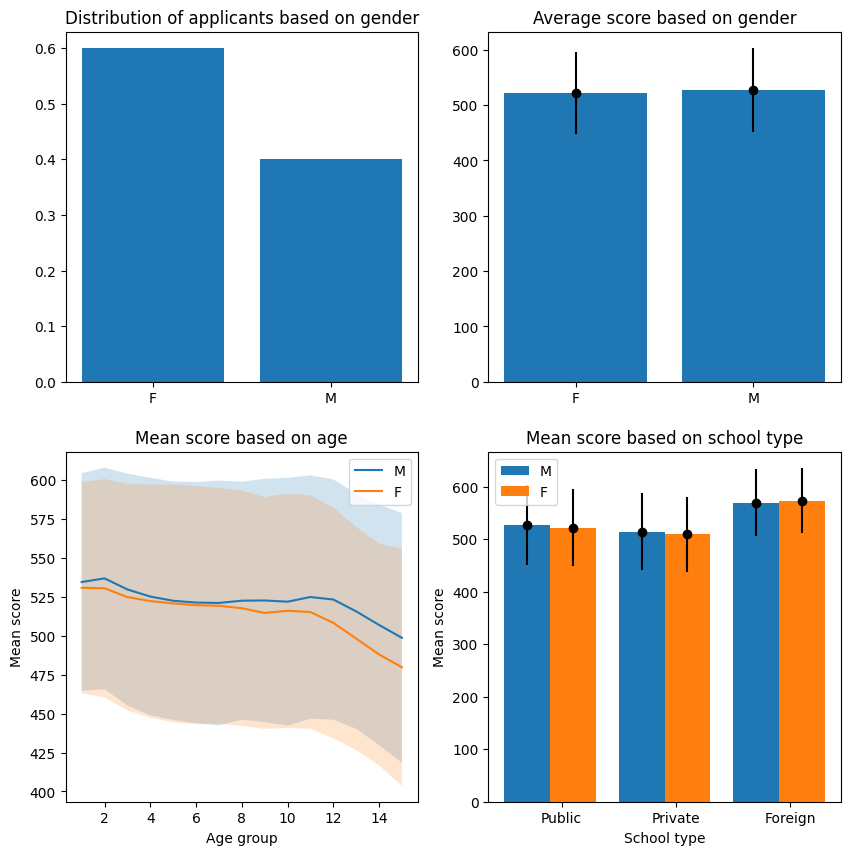

In [4]:

fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))


axs[0, 0].bar(
    [0, 1],
    df["TP_SEXO"].value_counts().values / df["TP_SEXO"].count(),
)
axs[0, 0].set_xticks([0, 1])
axs[0, 0].set_xticklabels(["F", "M"])
axs[0, 0].set_title("Distribution of applicants based on gender")


axs[0, 1].bar(
    [0, 1],
    df.groupby("TP_SEXO")["target"].mean().values
)
axs[0, 1].errorbar(
    [0, 1],
    df.groupby("TP_SEXO")["target"].mean().values,
    yerr=df.groupby("TP_SEXO")["target"].std().values,
    color="black",
    fmt="o",
)
axs[0, 1].set_xticks([0, 1])
axs[0, 1].set_xticklabels(["F", "M"])
axs[0, 1].set_title("Average score based on gender")



def simplify_age(age):
    return age // 4 * 4

#df["age"] = df["NU_IDADE"].apply(simplify_age)

for i in ["M", "F"]:
    df_filter = df[df["TP_SEXO"] == i]
    df_filter_mean = df_filter.groupby("TP_FAIXA_ETARIA")["target"].mean().reset_index()
    axs[1, 0].plot(
        df_filter_mean["TP_FAIXA_ETARIA"],
        df_filter_mean["target"],
        label=i,
    )

    df_filter_std = df_filter.groupby("TP_FAIXA_ETARIA")["target"].std().reset_index()
    axs[1, 0].fill_between(
        df_filter_mean["TP_FAIXA_ETARIA"],
        df_filter_mean["target"] - df_filter_std["target"],
        df_filter_mean["target"] + df_filter_std["target"],
        alpha=0.2,
    )


axs[1, 0].set_title("Mean score based on age")
axs[1, 0].set_xlabel("Age group")
axs[1, 0].set_ylabel("Mean score")
axs[1, 0].legend()

#df["COMBINED_SCHOOL"] = df["TP_ESCOLA"] * 10000 # + df["TP_DEPENDENCIA_ADM_ESC"]
df["COMBINED_SCHOOL"] = df["TP_ESCOLA"]

labels_school = ["Public", "Private", "Foreign"]
for i, g in enumerate(["M", "F"]):
    df_filter = df[df["TP_SEXO"] == g]
    unique_schools = df_filter["COMBINED_SCHOOL"].unique()
    axs[1, 1].bar(
        np.arange(len(unique_schools)) + i * 0.4 + 0.1,
        df_filter.groupby("COMBINED_SCHOOL")["target"].mean().values,
        width=0.4,
        label=g,
    )
    df_filter_std = df_filter.groupby("COMBINED_SCHOOL")["target"].std().values
    axs[1, 1].errorbar(
        np.arange(len(unique_schools)) + i * 0.4 + 0.1,
        df_filter.groupby("COMBINED_SCHOOL")["target"].mean().values,
        yerr=df_filter_std,
        color="black",
        fmt="o",
    )
axs[1, 1].set_xticks(np.arange(len(unique_schools)) + 0.4)
axs[1, 1].set_xticklabels(labels_school)
axs[1, 1].set_title("Mean score based on school type")
axs[1, 1].set_xlabel("School type")
axs[1, 1].set_ylabel("Mean score")
axs[1, 1].legend()

plt.show()


In [33]:
score_threshold = 400
data = {}
col = ["M", "F"]
data["group_likelihoods"] = [
    df[df["TP_SEXO"] == i].shape[0] / df.shape[0] for i in col
]

n_school_type = df["TP_ESCOLA"].nunique()
n_age = df["TP_FAIXA_ETARIA"].nunique()

school_types = df["TP_ESCOLA"].unique()
age_types = df["TP_FAIXA_ETARIA"].unique()
school_types.sort()
age_types.sort()


data["cluster_probabilities"] = []
data["success_probabilities"] = []

for z in col:
    data["cluster_probabilities"].append([])
    data["success_probabilities"].append([])

    for school in school_types:
        for age in age_types:
            df_filter = df[
                (df["TP_ESCOLA"] == school) & (df["TP_FAIXA_ETARIA"] == age) & (df["TP_SEXO"] == z)
            ]

            data["cluster_probabilities"][-1].append(
                df_filter.shape[0] / (df["TP_SEXO"] == z).sum() if (df["TP_SEXO"] == z).sum() > 0 else 0
            )
            y = df_filter["target"].values
            y = y > score_threshold
            data["success_probabilities"][-1].append(
                np.mean(y) if len(y) > 0 else 0
            )


# add more one cluster that has probability 
for i in range(len(col)):
    data["cluster_probabilities"][i].append(0)
    data["success_probabilities"][i].append(1)


#with open("data/enem.pkl", "wb") as f:
#    pkl.dump(data, f)

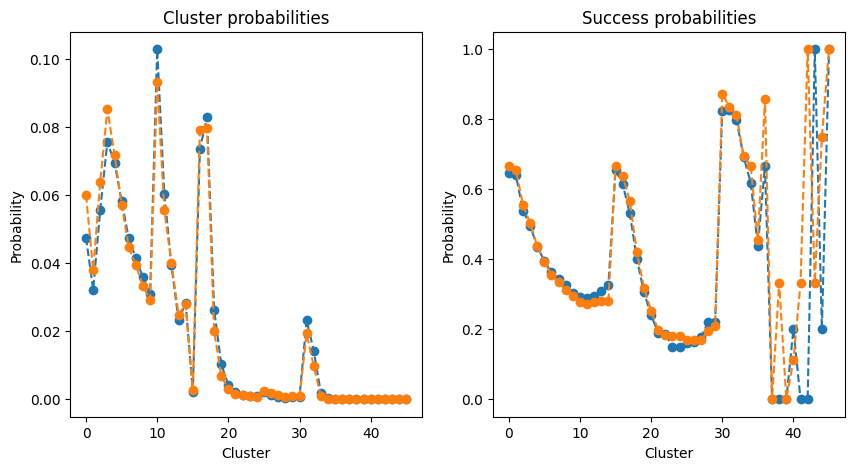

In [34]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))

for i, z in enumerate(col):
    axs[0].plot(
        data["cluster_probabilities"][i],
        label=z,
        marker="o",
        linestyle="--",
    )

    axs[1].plot(
        data["success_probabilities"][i],
        label=z,
        marker="o",
        linestyle="--",
    )

axs[0].set_title("Cluster probabilities")
axs[1].set_title("Success probabilities")


for i in range(2):
    axs[i].set_xlabel("Cluster")
    axs[i].set_ylabel("Probability")

plt.show()

In [38]:
def simplify_class(c):
    if c in ["A", "B", "C", "D", "E"]:
        return "A"
    if c in ["F", "G", "H", "I", "J"]:
        return "B"
    else:
        return "C"

df["Q006_simple"] = df["Q006"].apply(simplify_class)

def simplify_race(c):
    if c == 1:
        return "White"
    else:
        return "Black"
df["TP_COR_RACA_simple"] = df["TP_COR_RACA"].apply(simplify_race)

In [36]:
score_threshold = 400
data = {}
col = ["M", "F"]
data["group_likelihoods"] = [
    df[df["TP_SEXO"] == i].shape[0] / df.shape[0] for i in col
]

n_school_type = df["Q006_simple"].nunique()
n_age = df["TP_FAIXA_ETARIA"].nunique()

school_types = df["Q006_simple"].unique()
age_types = df["TP_FAIXA_ETARIA"].unique()
school_types.sort()
age_types.sort()


data["cluster_probabilities"] = []
data["success_probabilities"] = []

for z in col:
    data["cluster_probabilities"].append([])
    data["success_probabilities"].append([])

    for school in school_types:
        for age in age_types:
            df_filter = df[
                (df["Q006_simple"] == school) & (df["TP_FAIXA_ETARIA"] == age) & (df["TP_SEXO"] == z)
            ]

            data["cluster_probabilities"][-1].append(
                df_filter.shape[0] / (df["TP_SEXO"] == z).sum() if (df["TP_SEXO"] == z).sum() > 0 else 0
            )
            y = df_filter["target"].values
            y = y > score_threshold
            data["success_probabilities"][-1].append(
                np.mean(y) if len(y) > 0 else 0
            )


# add more one cluster that has probability 
for i in range(len(col)):
    data["cluster_probabilities"][i].append(0)
    data["success_probabilities"][i].append(1)


#with open("data/enem.pkl", "wb") as f:
#    pkl.dump(data, f)

In [39]:
score_threshold = 400
data = {}
col = ["White", "Black"]
data["group_likelihoods"] = [
    df[df["TP_COR_RACA_simple"] == i].shape[0] / df.shape[0] for i in col
]

n_school_type = df["Q006_simple"].nunique()
n_age = df["TP_FAIXA_ETARIA"].nunique()

school_types = df["Q006_simple"].unique()
age_types = df["TP_FAIXA_ETARIA"].unique()
school_types.sort()
age_types.sort()


data["cluster_probabilities"] = []
data["success_probabilities"] = []

for z in col:
    data["cluster_probabilities"].append([])
    data["success_probabilities"].append([])

    for school in school_types:
        for age in age_types:
            df_filter = df[
                (df["Q006_simple"] == school) & (df["TP_FAIXA_ETARIA"] == age) & (df["TP_COR_RACA_simple"] == z)
            ]

            data["cluster_probabilities"][-1].append(
                df_filter.shape[0] / (df["TP_COR_RACA_simple"] == z).sum() if (df["TP_COR_RACA_simple"] == z).sum() > 0 else 0
            )
            y = df_filter["target"].values
            y = y > score_threshold
            data["success_probabilities"][-1].append(
                np.mean(y) if len(y) > 0 else 0
            )


# add more one cluster that has probability 
for i in range(len(col)):
    data["cluster_probabilities"][i].append(0)
    data["success_probabilities"][i].append(1)


#with open("data/enem.pkl", "wb") as f:
#    pkl.dump(data, f)

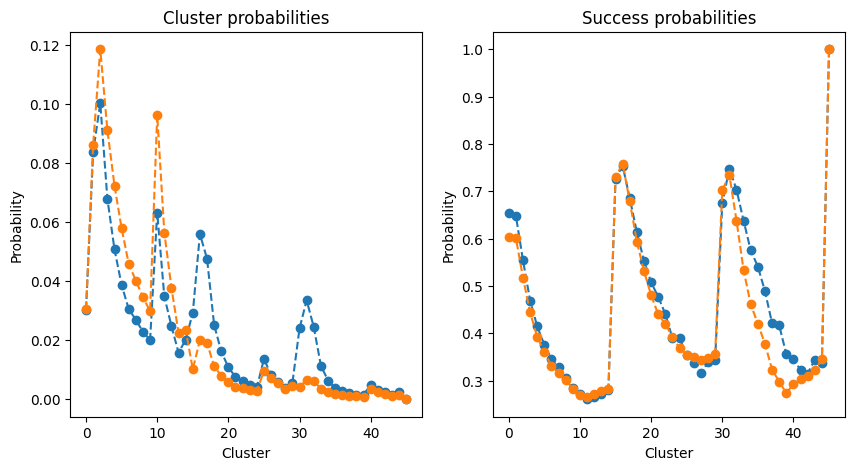

In [40]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))

for i, z in enumerate(col):
    axs[0].plot(
        data["cluster_probabilities"][i],
        label=z,
        marker="o",
        linestyle="--",
    )

    axs[1].plot(
        data["success_probabilities"][i],
        label=z,
        marker="o",
        linestyle="--",
    )

axs[0].set_title("Cluster probabilities")
axs[1].set_title("Success probabilities")


for i in range(2):
    axs[i].set_xlabel("Cluster")
    axs[i].set_ylabel("Probability")

plt.show()

In [41]:
with open("data/enem.pkl", "wb") as f:
    pkl.dump(data, f)